<a href="https://colab.research.google.com/github/pmhiremath/FinEDA-FE-Financial-Exploratory-Data-Analysis-Feature-Engineering-Pipeline/blob/main/Financial_pipeline_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

### **Author** : [Prajwal kapnoor]

### **Project Overview**

*   **Dataset** : S&P 500 Stock Data (Kaggle) — historical OHLCV prices
*   **Stack** : Python | Pandas | NumPy | Scikit-Learn | Matplotlib | Seaborn
*   **Purpose** : End-to-end pipeline from raw CSV to a model-ready feature matrix

---

#  Financial Dataset Analyzer & Feature Engineer
#  Jupyter / Google Colab — Cell-by-Cell Version
#  Run each cell top to bottom in order


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & Global Settings
# ─────────────────────────────────────────────────────────────────────────────

In [16]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2a4a",
    "figure.dpi":       150,
})

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Generate Synthetic Dataset
#
# WHY: This simulates the real Kaggle S&P 500 CSV schema (Date, Open, High,
#      Low, Close, Volume, Name) with realistic messiness baked in:
#        - ~3% missing values  (NaN) across price columns
#        - ~1% outlier spikes  (fat-finger / data-feed errors)
#        - Date stored as string instead of datetime (wrong dtype on purpose)
#
# In Colab with the real Kaggle file, replace this cell with:
#   raw_df = pd.read_csv("all_stocks_5yr.csv")
# ─────────────────────────────────────────────────────────────────────────────

In [17]:
tickers = ["AAPL", "GOOGL", "MSFT", "AMZN", "TSLA"]
start   = "2018-01-01"
end     = "2023-12-31"
seed    = 42

rng   = np.random.default_rng(seed)
dates = pd.date_range(start, end, freq="B")         # business days only

records = []

for ticker in tickers:
    n = len(dates)

    # Geometric Brownian Motion — realistic stock price simulation
    S0     = rng.uniform(50, 500)
    mu     = rng.uniform(0.0001, 0.0003)
    sigma  = rng.uniform(0.01, 0.025)
    shocks = rng.standard_normal(n)
    close  = S0 * np.cumprod(np.exp((mu - 0.5 * sigma**2) + sigma * shocks))

    spread  = rng.uniform(0.005, 0.015, n)
    high    = close * (1 + spread)
    low     = close * (1 - spread)
    open_   = close * (1 + rng.uniform(-0.005, 0.005, n))
    volume  = rng.integers(1_000_000, 50_000_000, n).astype(float)

    df_t = pd.DataFrame({
        "Date":   dates.astype(str),               # intentionally wrong dtype
        "Open":   np.round(open_,  2),
        "High":   np.round(high,   2),
        "Low":    np.round(low,    2),
        "Close":  np.round(close,  2),
        "Volume": volume,
        "Name":   ticker,
    })

    # Inject ~3% NaNs
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        mask = rng.random(n) < 0.03
        df_t.loc[mask, col] = np.nan

    # Inject ~1% price outlier spikes (fat-finger errors)
    for col in ["Close", "High"]:
        spike_idx = rng.choice(n, size=int(n * 0.01), replace=False)
        df_t.loc[spike_idx, col] *= rng.uniform(1.5, 3.0, len(spike_idx))

    records.append(df_t)

raw_df = pd.concat(records, ignore_index=True)

print(f"✓ Dataset generated")
print(f"  Shape   : {raw_df.shape}")
print(f"  Tickers : {tickers}")
print(f"\n  Sample rows:")
raw_df.head()


✓ Dataset generated
  Shape   : (7825, 7)
  Tickers : ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

  Sample rows:


,Date,Open,High,Low,Close,Volume,Name
0,2018-01-01,408.89,410.70,403.13,406.91,18013891.0,AAPL
1,2018-01-02,389.81,392.75,385.49,389.12,7429043.0,AAPL
2,2018-01-03,375.93,380.51,374.83,377.67,15323949.0,AAPL
3,2018-01-04,380.14,383.58,373.92,378.75,32278658.0,AAPL
4,2018-01-05,375.48,380.77,371.21,375.99,29851303.0,AAPL


#
# CELL 3 — STEP 1: Data Extraction & Loading
#
# WHY: Pinning essential columns mirrors the usecols argument in pd.read_csv()
#      which limits memory on large files. Converting Date to datetime
#      immediately prevents silent string-comparison bugs that corrupt all
#      downstream time-series operations like rolling() and resample().
#

In [18]:


ESSENTIAL_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Volume", "Name"]
TICKER = "AAPL"

# Isolate essential columns (mirrors usecols= in pd.read_csv)
df = raw_df[ESSENTIAL_COLUMNS].copy()
print(f"\n[1.1]  Shape after column isolation : {df.shape}")

# Fix the wrong dtype — Date is currently a string object
df["Date"] = pd.to_datetime(df["Date"])

# Filter to one ticker for a focused single-asset pipeline
df = df[df["Name"] == TICKER].copy()
df.sort_values("Date", inplace=True)

# Set DatetimeIndex — required for all rolling/resample operations
df.set_index("Date", inplace=True)
df.drop(columns=["Name"], inplace=True)

print(f"[1.2]  Ticker '{TICKER}' isolated   : {df.shape}")
print(f"[1.3]  Index dtype                  : {df.index.dtype}")
print(f"\n[1.4]  First 5 rows:")
print(df.head())
print(f"\n[1.5]  Column dtypes:")
print(df.dtypes)


[1.1]  Shape after column isolation : (7825, 7)
[1.2]  Ticker 'AAPL' isolated   : (1565, 5)
[1.3]  Index dtype                  : datetime64[ns]

[1.4]  First 5 rows:
              Open    High     Low   Close      Volume
Date                                                  
2018-01-01  408.89  410.70  403.13  406.91  18013891.0
2018-01-02  389.81  392.75  385.49  389.12   7429043.0
2018-01-03  375.93  380.51  374.83  377.67  15323949.0
2018-01-04  380.14  383.58  373.92  378.75  32278658.0
2018-01-05  375.48  380.77  371.21  375.99  29851303.0

[1.5]  Column dtypes:
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — STEP 2: Exploratory Data Analysis
#
# WHY: In quant finance, "look before you leap" is risk management.
#      Skewness in returns signals fat tails (crash risk). Correlation
#      between OHLC columns often exceeds 0.99 — a multicollinearity red-flag
#      that EDA catches before it silently inflates model variance.
# ─────────────────────────────────────────────────────────

In [19]:

print("  STEP 2 — EXPLORATORY DATA ANALYSIS")


# 2.1 Summary statistics with skewness and kurtosis
desc = df.describe().T
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurtosis()
print(desc.round(3).to_string())

df.describe().dtypes

  STEP 2 — EXPLORATORY DATA ANALYSIS
         count          mean           std         min           25%          50%           75%           max  skewness  kurtosis
Open    1517.0  2.478840e+02  8.160500e+01      123.93  1.776000e+02       215.51  3.222000e+02  4.511000e+02     0.535    -1.055
High    1516.0  2.525050e+02  8.699900e+01      125.49  1.802850e+02       218.93  3.256720e+02  1.022372e+03     1.110     3.862
Low     1508.0  2.457510e+02  8.076100e+01      122.58  1.763120e+02       214.13  3.196220e+02  4.464400e+02     0.536    -1.062
Close   1524.0  2.512740e+02  8.976100e+01      124.04  1.781720e+02       216.22  3.235580e+02  9.597830e+02     1.278     4.019
Volume  1524.0  2.523356e+07  1.393231e+07  1015406.00  1.328966e+07  24783845.00  3.706331e+07  4.999800e+07     0.045    -1.156


,0
Open,float64
High,float64
Low,float64
Close,float64
Volume,float64


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — EDA Visualisations (3-panel dashboard)
# ─────────────────────────────────────────────────────────────────────────────

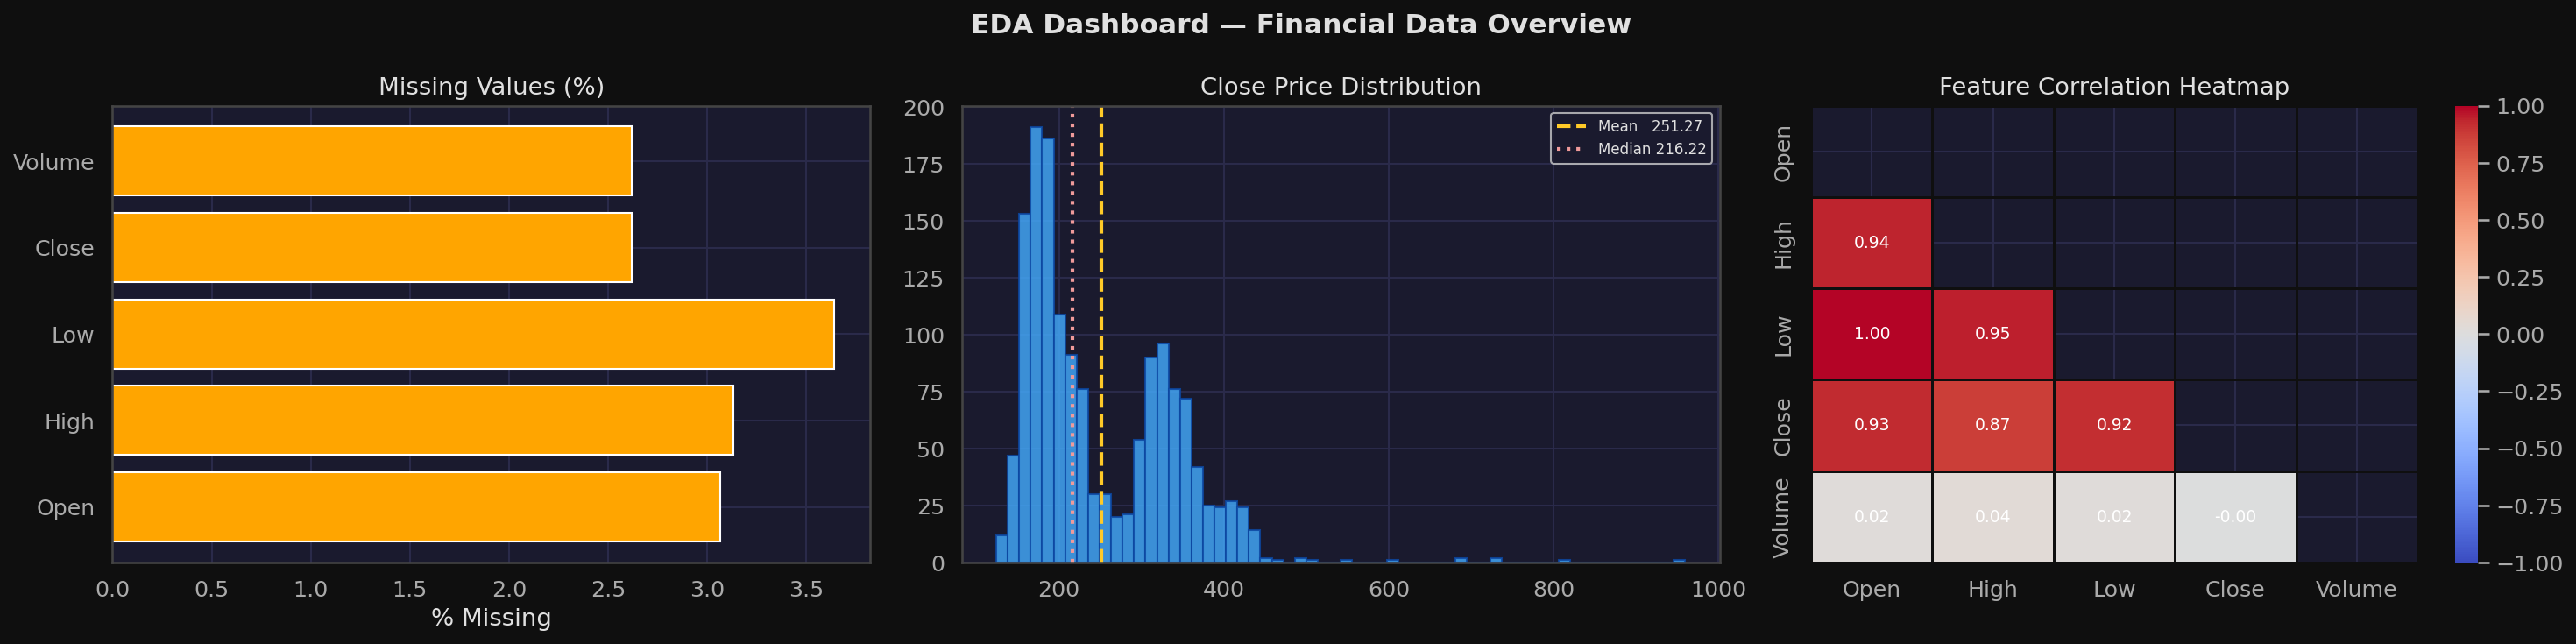

[SAVED] outputs/step2_eda_dashboard.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("EDA Dashboard — Financial Data Overview",
             fontsize=15, color="#e0e0e0", fontweight="bold")

# Panel 1 — Missing value bar chart
missing_pct = df.isnull().mean() * 100
axes[0].barh(
    missing_pct.index, missing_pct.values,
    color="orange"
)
axes[0].set_title("Missing Values (%)", color="#e0e0e0")
axes[0].set_xlabel("% Missing")

# Panel 2 — Close price distribution
clean_close = df["Close"].dropna()
axes[1].hist(clean_close, bins=60, color="#42a5f5", edgecolor="#0d47a1", alpha=0.85)
axes[1].axvline(clean_close.mean(),   color="#ffca28", lw=2, ls="--",
                label=f"Mean   {clean_close.mean():.2f}")
axes[1].axvline(clean_close.median(), color="#ef9a9a", lw=2, ls=":",
                label=f"Median {clean_close.median():.2f}")
axes[1].set_title("Close Price Distribution", color="#e0e0e0")
axes[1].legend(fontsize=8)

# Panel 3 — Correlation heatmap
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[2], annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="#0f0f0f",
    annot_kws={"size": 9, "color": "white"},
)
axes[2].set_title("Feature Correlation Heatmap", color="#e0e0e0")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/step2_eda_dashboard.png", bbox_inches="tight")
plt.show()
print(f"[SAVED] {OUTPUT_DIR}/step2_eda_dashboard.png")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — STEP 3: Data Cleaning
#
# WHY: Financial data has three endemic pathologies —
#   a) Missing values  : exchange holidays, API timeouts, vendor gaps
#   b) Outliers        : fat-finger errors, stock splits, erroneous ticks
#   c) Wrong dtypes    : Date as string breaks resample(), shift(), rolling()
#
# Forward-fill uses the last known price — the industry standard.
# 3×IQR clipping is robust to fat-tailed distributions unlike z-score.
# ─────────────────────────────────────────────────────────────────────────────

In [21]:


df_clean = df.copy()

# 3.1 Report missing values before cleaning
print("\n[3.1]  Missing values BEFORE cleaning:")
print(df_clean.isnull().sum().to_string())

# 3.2 Forward-fill prices (last known price is best estimate)
price_cols = ["Open", "High", "Low", "Close"]
df_clean[price_cols] = df_clean[price_cols].ffill()

# 3.3 Backward-fill any leading NaNs at the start of the series
df_clean[price_cols] = df_clean[price_cols].bfill()

# 3.4 Volume: fill with rolling median (volume is mean-reverting)
df_clean["Volume"] = df_clean["Volume"].fillna(
    df_clean["Volume"].rolling(10, min_periods=1).median()
)

print("\n[3.2]  Missing values AFTER cleaning:")
print(df_clean.isnull().sum().to_string())

# 3.5 Outlier clipping using IQR fence
print()
n_outliers_total = 0
for col in price_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR          # 3× fence is conservative for finance
    upper = Q3 + 3.0 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    n_outliers_total += n_out
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"[3.3]  {col:6s} — outliers clipped: {n_out:3d}  "
          f"fence=[{lower:.2f}, {upper:.2f}]")

print(f"\n[3.4]  Total outliers clipped : {n_outliers_total}")



[3.1]  Missing values BEFORE cleaning:
Open      48
High      49
Low       57
Close     41
Volume    41

[3.2]  Missing values AFTER cleaning:
Open      0
High      0
Low       0
Close     0
Volume    0

[3.3]  Open   — outliers clipped:   0  fence=[-255.94, 755.77]
[3.3]  High   — outliers clipped:   2  fence=[-258.59, 765.09]
[3.3]  Low    — outliers clipped:   0  fence=[-253.60, 749.22]
[3.3]  Close  — outliers clipped:   2  fence=[-259.29, 760.89]

[3.4]  Total outliers clipped : 4


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — STEP 4: Data Preprocessing
#
# WHY: ML algorithms (Ridge, SVM, KNN) are distance-based. Unscaled Volume
#      (~10^7) dominates Close (~10^2) in any L2 norm. StandardScaler
#      (mean=0, std=1) corrects this without distorting distributional shape.
#      Log-transforming Volume first fixes its heavy right skew.
# ─────────────────────────────────────────────────────────────────────────────

In [22]:


df_pre = df_clean.copy()

# 4.1 Log-transform Volume to fix right skew
df_pre["Log_Volume"] = np.log1p(df_pre["Volume"])
print("\n[4.1]  Log_Volume created (skew fix for heavy-tailed Volume)")

# 4.2 StandardScaler on numerical columns
scale_cols = ["Open", "High", "Low", "Close", "Log_Volume"]
scaler     = StandardScaler()
scaled_arr = scaler.fit_transform(df_pre[scale_cols])
df_scaled = pd.DataFrame(
    scaled_arr,
    columns=[f"{c}_scaled" for c in scale_cols],
    index=df_pre.index
)
df_pre = pd.concat([df_pre, df_scaled], axis=1)

print(f"[4.2]  Scaled columns added : {list(df_scaled.columns)}")
print(f"[4.3]  Shape after preprocessing : {df_pre.shape}")
print(f"\n[4.4]  Sample (first 3 rows):")
print(df_pre[["Close", "Close_scaled", "Volume", "Log_Volume"]].head(3))
df_pre


[4.1]  Log_Volume created (skew fix for heavy-tailed Volume)
[4.2]  Scaled columns added : ['Open_scaled', 'High_scaled', 'Low_scaled', 'Close_scaled', 'Log_Volume_scaled']
[4.3]  Shape after preprocessing : (1565, 11)

[4.4]  Sample (first 3 rows):
             Close  Close_scaled      Volume  Log_Volume
Date                                                    
2018-01-01  406.91      1.763625  18013891.0   16.706654
2018-01-02  389.12      1.562612   7429043.0   15.820908
2018-01-03  377.67      1.433236  15323949.0   16.544928


,Open,High,Low,Close,Volume,Log_Volume,Open_scaled,High_scaled,Low_scaled,Close_scaled,Log_Volume_scaled
Date,,,,,,,,,,,
2018-01-01,408.89,410.70,403.13,406.91,18013891.0,16.706654,1.971778,1.840898,1.950037,1.763625,-0.130011
2018-01-02,389.81,392.75,385.49,389.12,7429043.0,15.820908,1.738107,1.631799,1.731898,1.562612,-1.236028
2018-01-03,375.93,380.51,374.83,377.67,15323949.0,16.544928,1.568120,1.489215,1.600075,1.433236,-0.331956
2018-01-04,380.14,383.58,373.92,378.75,32278658.0,17.289917,1.619680,1.524977,1.588822,1.445439,0.598300
2018-01-05,375.48,380.77,371.21,375.99,29851303.0,17.211739,1.562609,1.492244,1.555310,1.414253,0.500680
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,131.74,132.85,131.33,132.09,16010965.0,16.588784,-1.422453,-1.395776,-1.411075,-1.341630,-0.277193
2023-12-26,129.80,130.69,127.84,132.09,7719414.0,15.859249,-1.446212,-1.420938,-1.454233,-1.341630,-1.188152
2023-12-27,127.71,129.29,125.50,127.39,10710772.0,16.186761,-1.471809,-1.437247,-1.483170,-1.394736,-0.779193


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — STEP 5: Financial Feature Engineering
#
# WHY: Raw OHLCV data is low-information. Feature engineering extracts the
#      signal that quants actually trade on. Every operation below is fully
#      vectorised using Pandas C extensions — 100-1000x faster than a loop.


In [23]:


df_feat = df_pre.copy()

# 5.1 Daily Return (%) — fundamental unit of risk/reward
df_feat["Daily_Return_Pct"] = df_feat["Close"].pct_change() * 100
print("[5.1]  Daily_Return_Pct  — pct_change()")

# 5.2 Log Return — used in options pricing and VaR models
df_feat["Log_Return"] = np.log(df_feat["Close"] / df_feat["Close"].shift(1))
print("[5.2]  Log_Return        — ln(Pt / Pt-1)")

# 5.3 Simple Moving Averages — trend filters at 3 timeframes
for window in [10, 20, 50]:
    df_feat[f"SMA_{window}"] = df_feat["Close"].rolling(window=window).mean()
print("[5.3]  SMA_10, SMA_20, SMA_50 — rolling mean")

# 5.4 Exponential Moving Average — reacts faster to recent price moves
df_feat["EMA_20"] = df_feat["Close"].ewm(span=20, adjust=False).mean()
print("[5.4]  EMA_20            — exponentially weighted mean")

# 5.5 Rolling Volatility — 20-day annualised std of log returns
#     Annualisation: σ_annual = σ_daily × √252 (trading days per year)
df_feat["Volatility_20D"] = df_feat["Log_Return"].rolling(20).std() * np.sqrt(252)
print("[5.5]  Volatility_20D    — annualised realised volatility")

# 5.6 Bollinger Bands — upper/lower price channels + width signal
rolling_std         = df_feat["Close"].rolling(20).std()
df_feat["BB_Upper"] = df_feat["SMA_20"] + 2 * rolling_std
df_feat["BB_Lower"] = df_feat["SMA_20"] - 2 * rolling_std
df_feat["BB_Width"] = (df_feat["BB_Upper"] - df_feat["BB_Lower"]) / df_feat["SMA_20"]
print("[5.6]  BB_Upper, BB_Lower, BB_Width — Bollinger Bands")

# 5.7 RSI (Relative Strength Index) — momentum oscillator 0-100
delta             = df_feat["Close"].diff()
gain              = delta.clip(lower=0).rolling(14).mean()
loss              = (-delta.clip(upper=0)).rolling(14).mean()
rs                = gain / loss.replace(0, np.nan)
df_feat["RSI_14"] = 100 - (100 / (1 + rs))
print("[5.7]  RSI_14            — momentum oscillator (0-100)")

# 5.8 MACD — trend + momentum convergence/divergence signal
ema_12                  = df_feat["Close"].ewm(span=12, adjust=False).mean()
ema_26                  = df_feat["Close"].ewm(span=26, adjust=False).mean()
df_feat["MACD"]         = ema_12 - ema_26
df_feat["MACD_Signal"]  = df_feat["MACD"].ewm(span=9, adjust=False).mean()
df_feat["MACD_Hist"]    = df_feat["MACD"] - df_feat["MACD_Signal"]
print("[5.8]  MACD, MACD_Signal, MACD_Hist")

# 5.9 ATR (Average True Range) — volatility for stop-loss sizing
high_low   = df_feat["High"] - df_feat["Low"]
high_close = (df_feat["High"] - df_feat["Close"].shift()).abs()
low_close  = (df_feat["Low"]  - df_feat["Close"].shift()).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_feat["ATR_14"] = true_range.rolling(14).mean()
print("[5.9]  ATR_14            — Average True Range")

# 5.10 Price-to-SMA20 ratio — mean-reversion signal
df_feat["Price_to_SMA20"] = df_feat["Close"] / df_feat["SMA_20"]
print("[5.10] Price_to_SMA20   — mean-reversion proxy")

# 5.11 Trend Signal — vectorised np.where (no Python loop)
#      Rule: Close > SMA_20 AND SMA_20 > SMA_50 → confirmed uptrend
df_feat["Trend"] = np.where(
    (df_feat["Close"] > df_feat["SMA_20"]) & (df_feat["SMA_20"] > df_feat["SMA_50"]),
    "Up",
    "Down",
)
le = LabelEncoder()
df_feat["Trend_Label"] = le.fit_transform(df_feat["Trend"])   # Up=1, Down=0
print("[5.11] Trend / Trend_Label — np.where vectorised signal")

# 5.12 Volume Z-Score — detects abnormal volume (informed trading signal)
vol_mean = df_feat["Volume"].rolling(20).mean()
vol_std  = df_feat["Volume"].rolling(20).std()
df_feat["Volume_ZScore"] = (df_feat["Volume"] - vol_mean) / vol_std.replace(0, np.nan)
print("[5.12] Volume_ZScore     — abnormal volume detection")

print(f"\n[5.13] Shape after feature engineering : {df_feat.shape}")

[5.1]  Daily_Return_Pct  — pct_change()
[5.2]  Log_Return        — ln(Pt / Pt-1)
[5.3]  SMA_10, SMA_20, SMA_50 — rolling mean
[5.4]  EMA_20            — exponentially weighted mean
[5.5]  Volatility_20D    — annualised realised volatility
[5.6]  BB_Upper, BB_Lower, BB_Width — Bollinger Bands
[5.7]  RSI_14            — momentum oscillator (0-100)
[5.8]  MACD, MACD_Signal, MACD_Hist
[5.9]  ATR_14            — Average True Range
[5.10] Price_to_SMA20   — mean-reversion proxy
[5.11] Trend / Trend_Label — np.where vectorised signal
[5.12] Volume_ZScore     — abnormal volume detection

[5.13] Shape after feature engineering : (1565, 30)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Feature Engineering Chart (4-panel time-series)
# ─────────────────────────────────────────────────────────────────────────────

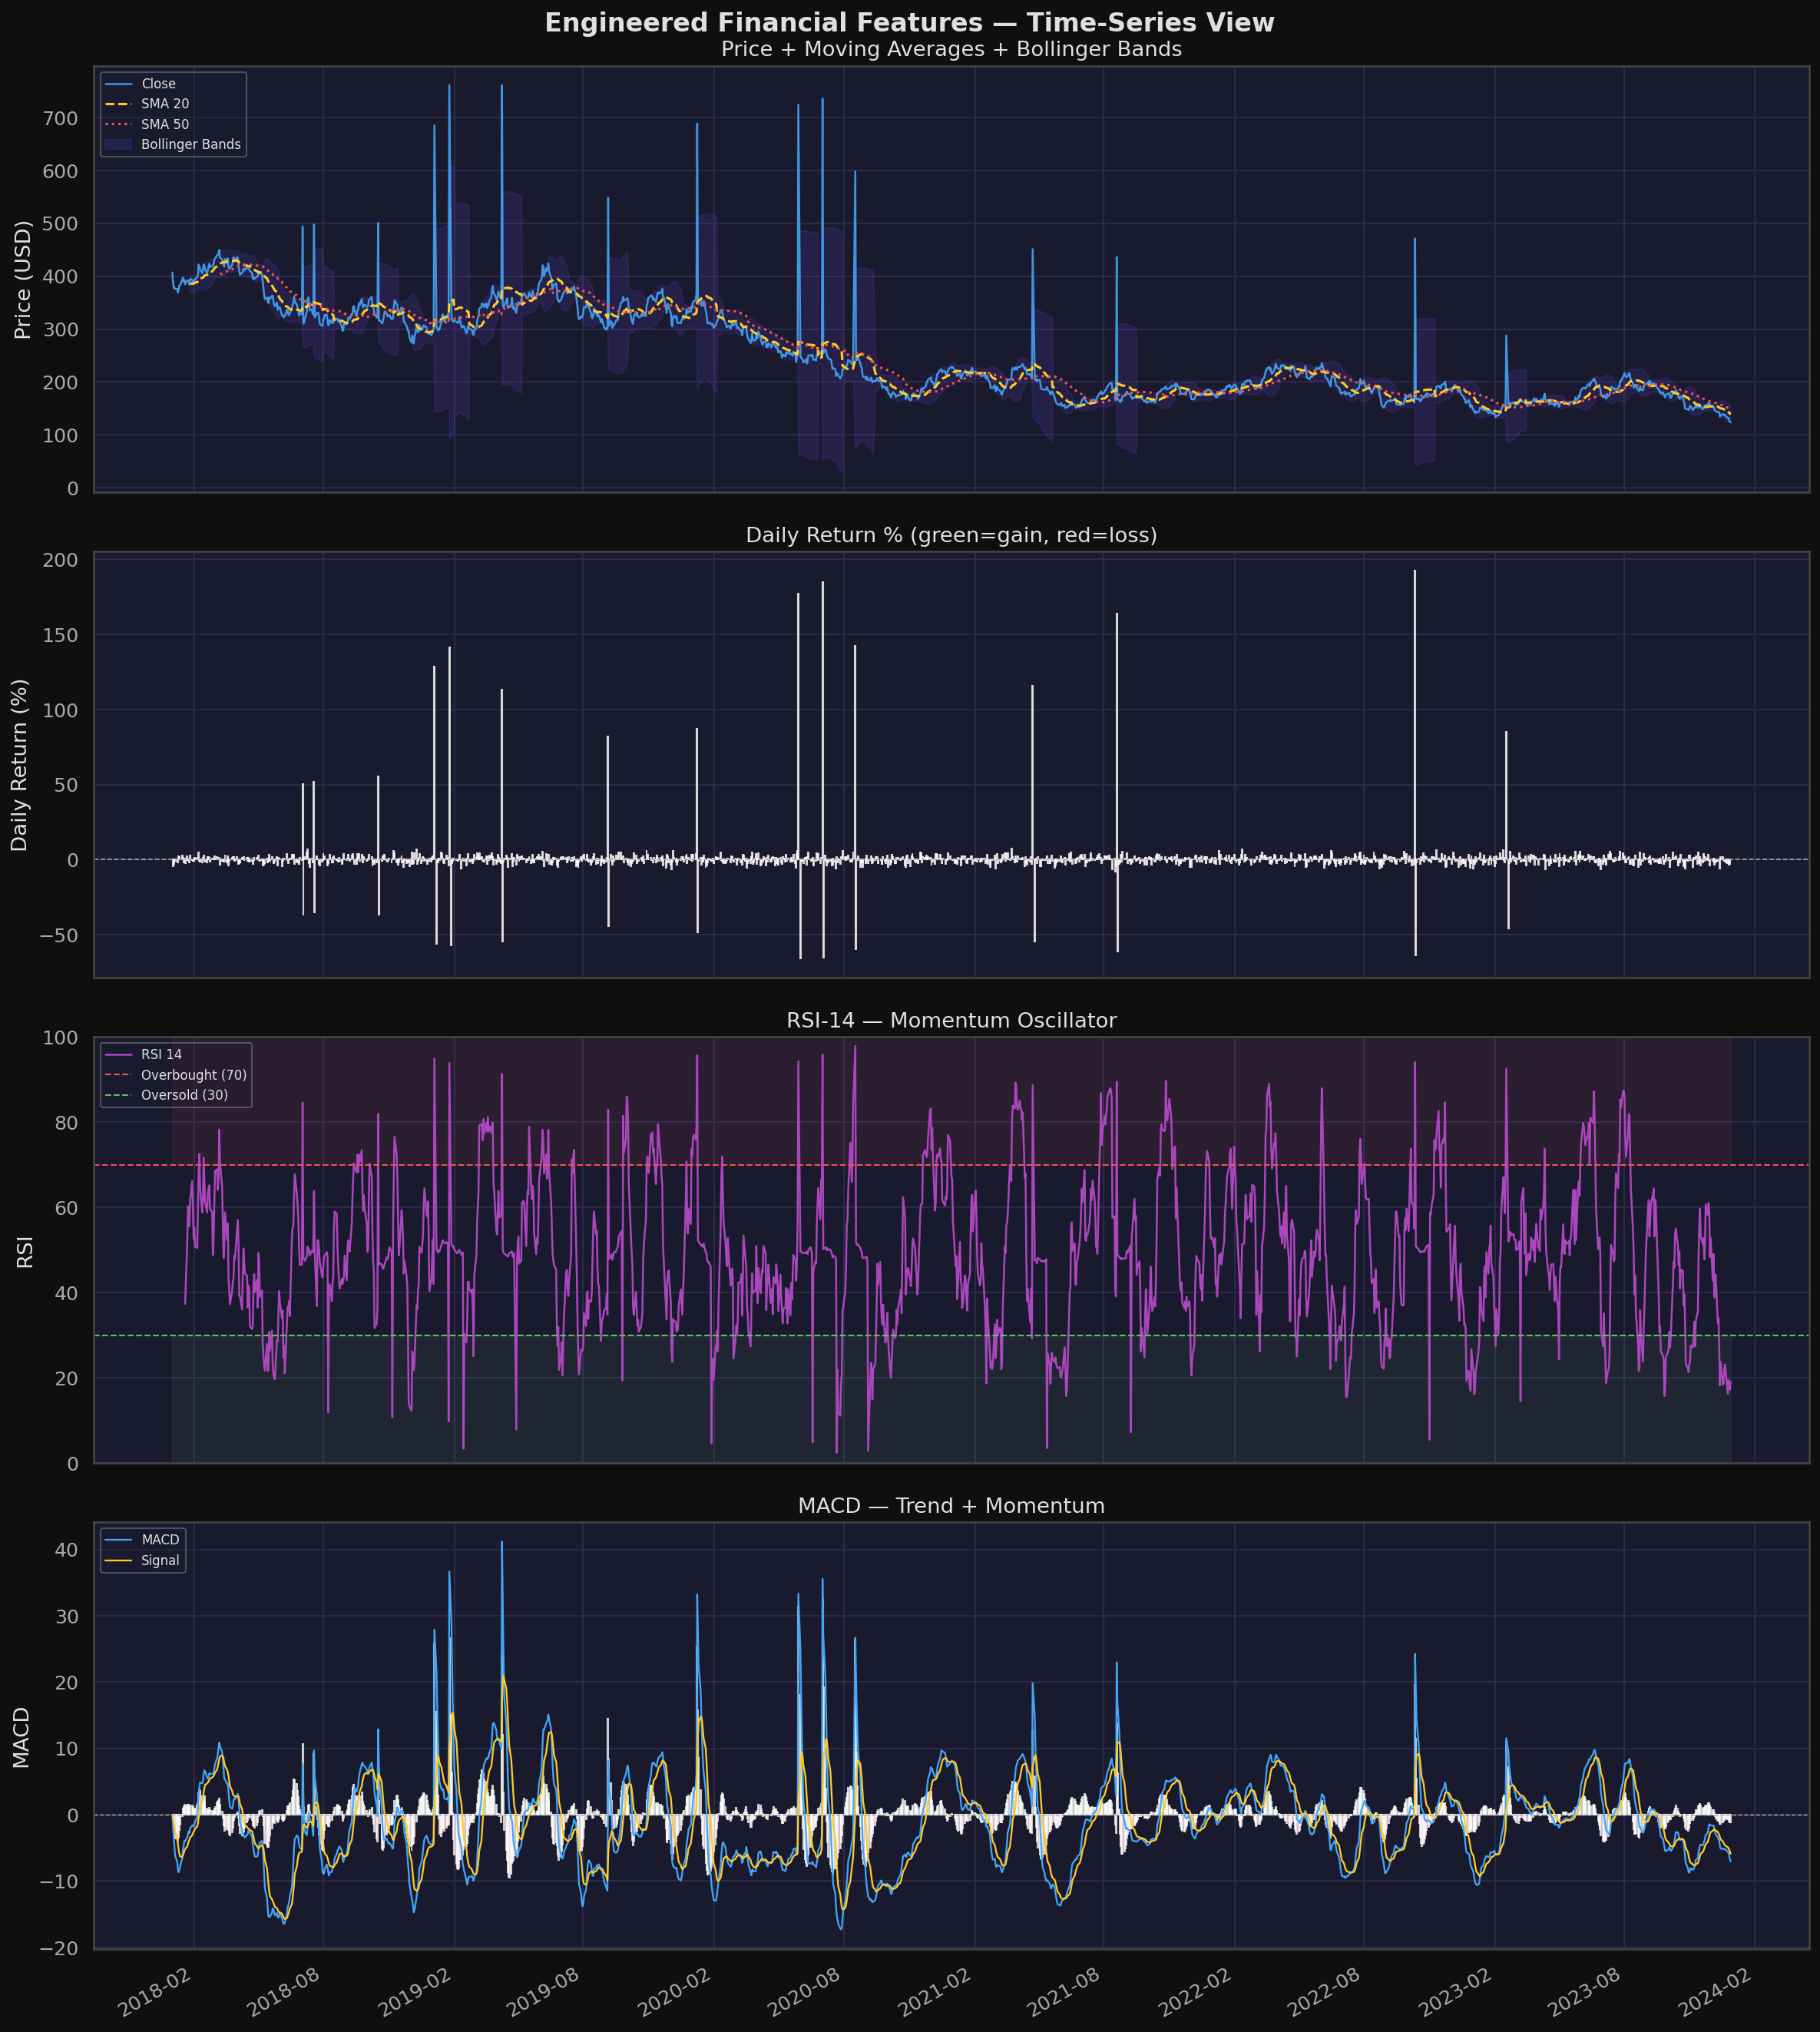

[SAVED] outputs/step5_engineered_features.png


In [24]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle("Engineered Financial Features — Time-Series View",
             fontsize=16, color="#e0e0e0", fontweight="bold", y=0.98)

# Panel 1 — Price + Moving Averages + Bollinger Bands
ax = axes[0]
ax.plot(df_feat.index, df_feat["Close"],   color="#42a5f5", lw=1.2, label="Close",  alpha=0.9)
ax.plot(df_feat.index, df_feat["SMA_20"],  color="#ffca28", lw=1.5, label="SMA 20", ls="--")
ax.plot(df_feat.index, df_feat["SMA_50"],  color="#ef5350", lw=1.5, label="SMA 50", ls=":")
ax.fill_between(df_feat.index, df_feat["BB_Upper"], df_feat["BB_Lower"],
                alpha=0.12, color="#7c4dff", label="Bollinger Bands")
ax.set_ylabel("Price (USD)", color="#e0e0e0")
ax.legend(loc="upper left", fontsize=8, framealpha=0.3)
ax.set_title("Price + Moving Averages + Bollinger Bands", color="#e0e0e0", pad=6)

# Panel 2 — Daily Return coloured by positive/negative
ax = axes[1]
colors = ["#66bb6a" if r >= 0 else "#ef5350"
          for r in df_feat["Daily_Return_Pct"].fillna(0)]
ax.bar(df_feat.index, df_feat["Daily_Return_Pct"].fillna(0),
       color=colors, width=1, alpha=0.8)
ax.axhline(0, color="#aaa", lw=0.8, ls="--")
ax.set_ylabel("Daily Return (%)", color="#e0e0e0")
ax.set_title("Daily Return % (green=gain, red=loss)", color="#e0e0e0", pad=6)

# Panel 3 — RSI with overbought/oversold zones
ax = axes[2]
ax.plot(df_feat.index, df_feat["RSI_14"], color="#ab47bc", lw=1.2, label="RSI 14")
ax.axhline(70, color="#ef5350", lw=1, ls="--", label="Overbought (70)")
ax.axhline(30, color="#66bb6a", lw=1, ls="--", label="Oversold (30)")
ax.fill_between(df_feat.index, 70, 100, alpha=0.08, color="#ef5350")
ax.fill_between(df_feat.index, 0,  30,  alpha=0.08, color="#66bb6a")
ax.set_ylim(0, 100)
ax.set_ylabel("RSI", color="#e0e0e0")
ax.legend(loc="upper left", fontsize=8, framealpha=0.3)
ax.set_title("RSI-14 — Momentum Oscillator", color="#e0e0e0", pad=6)

# Panel 4 — MACD histogram
ax = axes[3]
macd_colors = ["#66bb6a" if v >= 0 else "#ef5350"
               for v in df_feat["MACD_Hist"].fillna(0)]
ax.bar(df_feat.index, df_feat["MACD_Hist"].fillna(0),
       color=macd_colors, width=1, alpha=0.75)
ax.plot(df_feat.index, df_feat["MACD"],        color="#42a5f5", lw=1.1, label="MACD")
ax.plot(df_feat.index, df_feat["MACD_Signal"], color="#ffca28", lw=1.1, label="Signal")
ax.axhline(0, color="#aaa", lw=0.7, ls="--")
ax.set_ylabel("MACD", color="#e0e0e0")
ax.legend(loc="upper left", fontsize=8, framealpha=0.3)
ax.set_title("MACD — Trend + Momentum", color="#e0e0e0", pad=6)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/step5_engineered_features.png", bbox_inches="tight")
plt.show()
print(f"[SAVED] {OUTPUT_DIR}/step5_engineered_features.png")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — STEP 6: Feature Selection
#
# WHY: Multicollinearity inflates model variance and degrades interpretability.
#      SMA_10 / SMA_20 / SMA_50 and Close are near-perfectly correlated
#      (r ≈ 0.99). Keeping all of them is redundant and causes coefficient
#      instability in any regularised model.
#
#      Strategy:
#        a) Drop NaN rows from rolling window warmup period
#        b) VarianceThreshold  — removes near-constant columns
#        c) Pearson |r| > 0.90 — removes high-correlation pairs
# ─────────────────────────────────────────────────────────────────────────────

In [25]:


df_sel = df_feat.copy()

# 6.1 Drop rows with NaN introduced by rolling window warmup (~first 50 rows)
n_before = len(df_sel)
df_sel.dropna(inplace=True)
print(f"\n[6.1]  Rows dropped (rolling warmup NaNs) : {n_before - len(df_sel)}")
print(f"       Remaining rows                     : {len(df_sel)}")

# 6.2 Keep only numeric columns
numeric_cols = df_sel.select_dtypes(include=[np.number]).columns.tolist()
df_numeric   = df_sel[numeric_cols].copy()

# 6.3 VarianceThreshold — drop near-constant columns
selector     = VarianceThreshold(threshold=0.01)
selector.fit(df_numeric)
low_var_mask = ~selector.get_support()
low_var_cols = df_numeric.columns[low_var_mask].tolist()
df_numeric   = df_numeric.loc[:, selector.get_support()]
print(f"\n[6.2]  Low-variance columns dropped : "
      f"{low_var_cols if low_var_cols else 'None'}")

# 6.4 Pearson |r| > 0.90 — drop one from each high-correlation pair
corr_matrix = df_numeric.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_cols   = [col for col in upper_tri.columns
               if any(upper_tri[col] > 0.90)]
df_numeric.drop(columns=drop_cols, inplace=True)

print(f"\n[6.3]  High-correlation columns dropped (|r| > 0.90):")
for c in drop_cols:
    print(f"       • {c}")


[6.1]  Rows dropped (rolling warmup NaNs) : 49
       Remaining rows                     : 1516

[6.2]  Low-variance columns dropped : None

[6.3]  High-correlation columns dropped (|r| > 0.90):
       • High
       • Low
       • Close
       • Log_Volume
       • Open_scaled
       • High_scaled
       • Low_scaled
       • Close_scaled
       • Log_Volume_scaled
       • Log_Return
       • SMA_10
       • SMA_20
       • SMA_50
       • EMA_20
       • BB_Width
       • Volume_ZScore


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Final Correlation Matrix Chart
# ─────────────────────────────────────────────────────────────────────────────

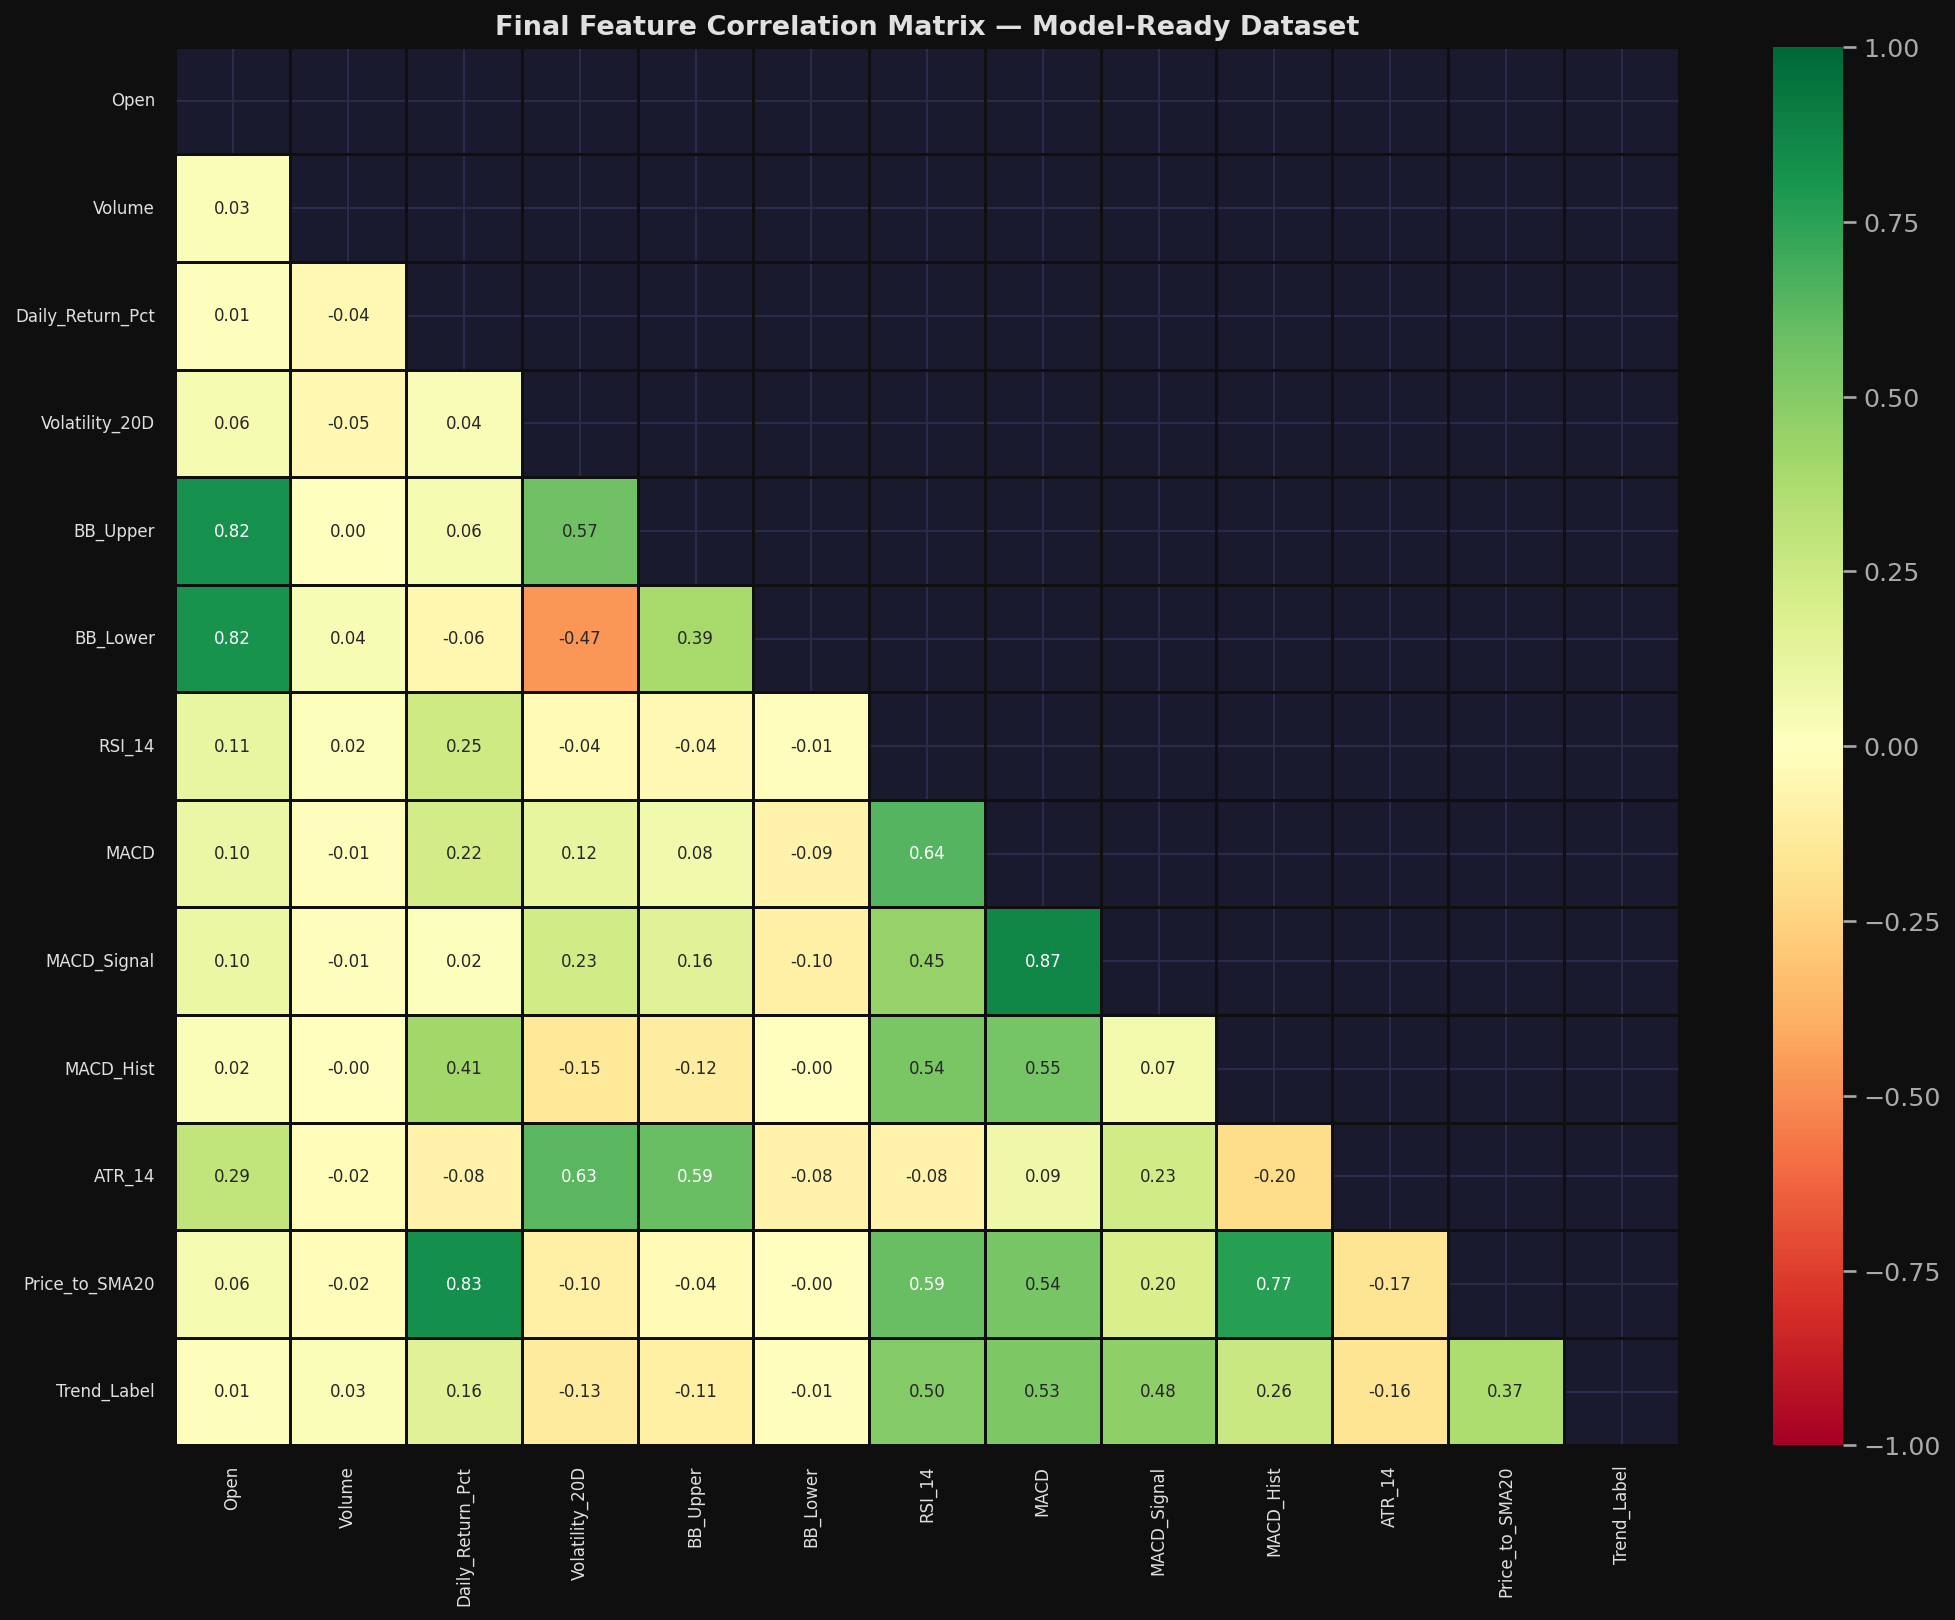

[SAVED] outputs/step6_final_correlation.png


In [26]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_final = df_numeric.corr()
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(
    corr_final, mask=mask, ax=ax, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="#0f0f0f",
    annot_kws={"size": 8},
)
ax.set_title("Final Feature Correlation Matrix — Model-Ready Dataset",
             fontsize=13, color="#e0e0e0", fontweight="bold")
ax.tick_params(colors="#e0e0e0", labelsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/step6_final_correlation.png", bbox_inches="tight")
plt.show()
print(f"[SAVED] {OUTPUT_DIR}/step6_final_correlation.png")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Final Model-Ready Dataset Output
# ─────────────────────────────────────────────────────────────────────────────

In [27]:
df_final = df_numeric.copy()

output_path = f"{OUTPUT_DIR}/model_ready_dataset.csv"
df_final.to_csv(output_path)

print("═" * 55)
print("  ✓ PIPELINE COMPLETE — FINAL MODEL-READY DATASET")
print("═" * 55)
print(f"\n  Shape   : {df_final.shape}")
print(f"  Columns : {list(df_final.columns)}")
print(f"  Saved   : {output_path}")
print(f"\n  Head (first 3 rows):")
df_final.head(3)

═══════════════════════════════════════════════════════
  ✓ PIPELINE COMPLETE — FINAL MODEL-READY DATASET
═══════════════════════════════════════════════════════

  Shape   : (1516, 13)
  Columns : ['Open', 'Volume', 'Daily_Return_Pct', 'Volatility_20D', 'BB_Upper', 'BB_Lower', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ATR_14', 'Price_to_SMA20', 'Trend_Label']
  Saved   : outputs/model_ready_dataset.csv

  Head (first 3 rows):


,Open,Volume,Daily_Return_Pct,Volatility_20D,BB_Upper,BB_Lower,RSI_14,MACD,MACD_Signal,MACD_Hist,ATR_14,Price_to_SMA20,Trend_Label
Date,,,,,,,,,,,,,
2018-03-09,436.05,41611452.0,-3.286636,0.252152,449.508772,398.650228,70.620843,10.292709,8.813069,1.479640,10.600714,1.025562,1
2018-03-12,432.57,41611452.0,-0.735767,0.242536,449.468306,401.300694,64.800923,9.466777,8.943811,0.522966,10.522143,1.014894,1
2018-03-13,425.53,8913532.0,-1.077087,0.243753,449.334260,403.006740,56.602928,8.340856,8.823220,-0.482364,10.227857,1.002111,1
